In [37]:
import xarray as xr
import numpy as np
import pandas as pd
import json

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge


from scipy.stats import wasserstein_distance, spearmanr

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import torch
from torch.utils.data import TensorDataset, DataLoader
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import CenteredNorm
import numpy.ma as ma

import random

In [38]:
with open("../data/enviroment_bbox.json", "r") as f:
    bbox = json.load(f)

enviroment_bbox = [
    bbox["min_lon"],
    bbox["min_lat"],
    bbox["max_lon"],
    bbox["max_lat"]
]

Loading and aligning dataset...
Preprocessing and scaling...
Creating rolling windows...
Train: X torch.Size([120, 12, 14, 54, 37]) | y torch.Size([120, 1, 30, 17])
Val:   X torch.Size([24, 12, 14, 54, 37]) | y torch.Size([24, 1, 30, 17])
Test:  X torch.Size([12, 12, 14, 54, 37]) | y torch.Size([12, 1, 30, 17])
Calculating Variance Inflation Factor (VIF)...

--- VIF Results ---


,feature,VIF
8,PP,23.154387
7,CHL,11.255956
2,TOB,9.958886
6,ZO,9.084987
0,TO,6.945550
13,MCOS,5.057886
11,ZSD,4.905909
12,MSEN,4.036437
9,CDM,2.821191
3,MLOTST,2.377017



Suggested variables to drop (Correlation > 0.75): ['ZO', 'PP', 'CDM', 'ZSD']


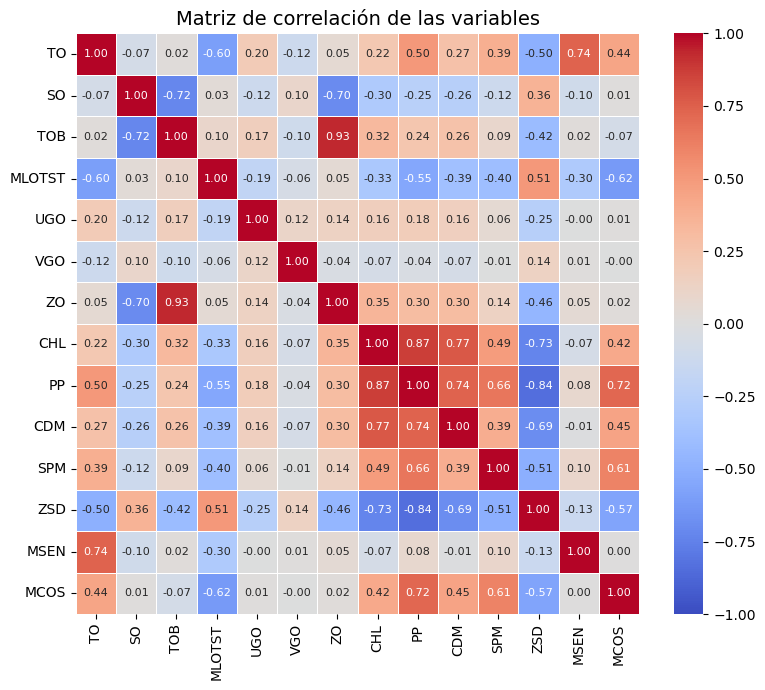

In [39]:
from dataset_loader import DataBuilder
sp = "SQA"
features = ["TO", "SO", "TOB", 
            "MLOTST", "UGO", "VGO", "ZO",
            "CHL", "PP", "CDM", "SPM", "ZSD",
            "MSEN", "MCOS", 
            ]
todas = False

data_builder = DataBuilder(target_var="cpue_index", sp=sp, features=features, 
                           prediction_horizon=1, forecast_lead=1, window_size=12,
                           start_date="2012-01-01", end_date="2025-12-31",
                            enviroment_bbox=enviroment_bbox
                            )

vars_names = data_builder.features
(X_train, y_train, m_train), (X_val, y_val, m_val), (X_test, y_test, m_test) = data_builder.get_splits()

def prep_ml_data(X, y, m=None):
    """
    Converts 5D input tensors and 3D target tensors into 2D arrays for ML
    """
    # Move to CPU and convert to numpy if dealing with PyTorch Tensors
    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(m, torch.Tensor):
        m = m.detach().cpu().numpy()

    N = X.shape[0]
    
    # Flatten features: (N, T, C, H_x, W_x) -> (N, T * C * H_x * W_x)
    X_rf = X.reshape(N, -1)
    
    # Flatten targets: (N, H_y, W_y) -> (N, H_y * W_y)
    y_rf = y.reshape(N, -1)
    
    if m is not None:
        m_rf = m.reshape(N, -1)
        return X_rf, y_rf, m_rf
    else:
        return X_rf, y_rf

X_train_ml, y_train_ml, m_train_ml = prep_ml_data(X_train, y_train, m_train)
X_val_ml, y_val_ml, m_val_ml = prep_ml_data(X_val, y_val, m_val)
X_test_ml, y_test_ml, m_test_ml = prep_ml_data(X_test, y_test, m_test)



prediction_horizon = y_test.shape[1]
H_val, W_val = y_val.shape[-2], y_val.shape[-1]
H_out, W_out = y_test.shape[-2], y_test.shape[-1]

m_true_val = m_val_ml.reshape(-1, prediction_horizon, H_val, W_val)
y_true_val = y_val_ml.reshape( -1, prediction_horizon, H_val, W_val)

m_true = m_test_ml.reshape(-1, prediction_horizon, H_out, W_out)
y_true = y_test_ml.reshape(-1, prediction_horizon, H_out, W_out)

mask_flat = m_test_ml.astype(bool)


data_builder.plot_correlations()

In [40]:
def compute_metrics(y_test_ml, y_pred_flat, y_true, mask_spatial):

    # =====================================================
    # Shapes
    # =====================================================
    # y_true:
    # (N, prediction_horizon, H, W)

    N, horizon, H_out, W_out = y_true.shape

    mask_spatial = np.asarray(mask_spatial).astype(bool)

    # =====================================================
    # 1. GLOBAL FLATTENED METRICS
    # =====================================================

    y_test_flat = np.asarray(y_test_ml).flatten()
    y_pred_flat_1d = np.asarray(y_pred_flat).flatten()
    mask_flat = mask_spatial.flatten()

    y_test_masked = y_test_flat[mask_flat]
    y_pred_masked = y_pred_flat_1d[mask_flat]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================

    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked,y_pred_masked)
    r2 = r2_score(y_test_masked,y_pred_masked)
    pearson_corr = pearsonr(y_test_masked,y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = (np.max(y_test_masked)- np.min(y_test_masked))
    
    if data_range_flat > 0:
        nrmse = rmse / data_range_flat
    else:
        nrmse = np.nan    
        
    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
        
    spearman_corr, p_val = spearmanr(y_test_masked,y_pred_masked)

    # =====================================================
    # 3. RESTORE 4D SHAPE
    # =====================================================

    y_pred4D = np.asarray(y_pred_flat).reshape(N, horizon, H_out, W_out)

    # =====================================================
    # 4. SSIM
    # =====================================================

    valid_true = y_true[mask_spatial]

    data_range = (valid_true.max()- valid_true.min())
        
        
    

    ssim_scores = []

    # Need two loops now:
    # one over forecast samples
    # one over forecast horizons
    for i in range(N):
        for h in range(horizon):
            current_mask = mask_spatial[i, h]
            # Skip if this grid contains no valid pixels
            if not np.any(current_mask):
                continue

            _, ssim_map = ssim( y_true[i, h], y_pred4D[i, h], data_range=data_range, win_size=5, full=True)

            valid_ssim_pixels = ssim_map[current_mask]

            if len(valid_ssim_pixels) > 0:
                ssim_scores.append(np.mean(valid_ssim_pixels))
                    
    if len(ssim_scores) > 0:
        mean_ssim = np.mean(ssim_scores)
    else:
        mean_ssim = np.nan

    # =====================================================
    # 5. Per month metrics
    # =====================================================
    for h in range(horizon):
        y_true_h = y_true[:, h, :, :]
        y_pred_h = y_pred4D[:, h, :, :]
        mask_h = mask_spatial[:, h, :, :]

        # Flatten automatically by boolean masking
        y_true_h_masked = y_true_h[mask_h]
        y_pred_h_masked = y_pred_h[mask_h]

        if len(y_true_h_masked) > 1:
            r2_h = r2_score(y_true_h_masked, y_pred_h_masked)
        else:
            r2_h = np.nan

        print(f"Month +{h + 1}: R² = {r2_h:.4f}", f"{y_pred_h_masked.shape}")
    # =====================================================
    # 6. RETURN
    # =====================================================
    metrics = [r2, pearson_corr, mean_ssim, rmse, nrmse, mae, mbe, w_dist, spearman_corr]


    return metrics

In [41]:
iters = 2
columns = ["r2", "pearson_corr","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr"]
metrics_df = pd.DataFrame(columns=columns)
importance_all_df = pd.DataFrame(columns=vars_names)

for i in range(iters):
    model = RandomForestRegressor(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=random.randint(0, 1000))

    model.fit(X_train_ml, y_train_ml)

    y_pred_flat = model.predict(X_test_ml)

    metrics = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
    metrics_df.loc[len(metrics_df)] = metrics


    # -------- Feature Importance Extraction --------
    raw_importances = model.feature_importances_
    T = X_train.shape[1]   # window (12)
    C = X_train.shape[2]   # number of variables/channels
    H_x = X_train.shape[3] # height (lat)
    W_x = X_train.shape[4] # width (lon)

    reshaped_importances = raw_importances.reshape(T, C, H_x, W_x)

    variable_importances = reshaped_importances.sum(axis=(0, 2, 3))


    importance_all_df.loc[len(importance_all_df)] = variable_importances


importance_summary_df = pd.DataFrame({"Variable": vars_names, 
                                      "Importance": [f"{importance_all_df[var].mean():.3f}±{importance_all_df[var].std():.3f}"for var in vars_names],
                                      "Mean Importance": [importance_all_df[var].mean()for var in vars_names]})

# Sort by mean importance
importance_summary_df = importance_summary_df.sort_values(by="Mean Importance",ascending=False).reset_index(drop=True)

# Optional: remove helper column before saving
importance_summary_df = importance_summary_df.drop(columns=["Mean Importance"])

metrics_summary_df = pd.DataFrame(
{col: [f"{metrics_df[col].mean():.3f}±{metrics_df[col].std():.3f}"]for col in metrics_df.columns})

# save everyhtng to a excel workbook
model_name = model.__class__.__name__
sheet_name = f"{model_name}_{sp}"
if todas:
    sheet_name = f"{model_name}_{sp}_todas"

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    importance_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_summary_df) + 3, index=False)


Month +1: R² = 0.5106 (1500,)
Month +1: R² = 0.5049 (1500,)


In [42]:
display(metrics_summary_df)
display(importance_summary_df)


,r2,pearson_corr,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr
0,0.508±0.004,0.718±0.002,0.394±0.004,1.244±0.005,0.108±0.000,0.745±0.001,-0.023±0.003,0.480±0.004,0.616±0.000


,Variable,Importance
0,PP,0.294±0.009
1,TO,0.109±0.002
2,MLOTST,0.089±0.001
3,SPM,0.073±0.002
4,CHL,0.063±0.006
5,ZSD,0.062±0.001
6,UGO,0.054±0.001
7,VGO,0.051±0.002
8,CDM,0.046±0.000
9,ZO,0.045±0.000
